
# Infraslow sigma-power oscillation — grand-average Fig C from precomputed spectra (N2 / N3 / NREM)

Same Fig C grand-average plot as `demo_infraslow_yasa_average.ipynb`, but for the
full cohort and reading **only** the precomputed empirical spectra that
`src/run_all_metrics.py` already wrote to `$SCRATCH/results/spectra/{ID}_spectra.npz`
-- no raw EDFs, no `all_metrics.csv`. Each subject's file holds the bout-averaged,
baseline-corrected relative spectrum per stage (`{stage}_freqs` /
`{stage}_corr_mean`, see `infraslow.processing.subject_pipeline`),
so that's the only curve available here -- all three panels below are built from it,
unlike the demo's left panel, which used the pre-correction relative spectrum.

The empirical curve rises steeply then decays slowly (asymmetric/right-skewed), so
unlike the demo's symmetric Gaussian, the fit here is an asymmetric **bi-Gaussian**
(independent left/right SDs sharing one peak) -- a symmetric fit pulls the peak
away from the true empirical one to find a shape compromise.

For each of the three stage groups (**N2**, **N3**, **NREM**) this produces one
three-panel figure:

- **A)** grand-average relative spectral power (mean +/- SEM),
- **B)** the same curve with a fresh bi-Gaussian ISFS fit, baseline, AUC (+/-1 SD)
  and bandwidth,
- **C)** the same fit again, plus the **chromatogram peak area** -- the fit
  integrated above a sloped baseline down to where it crosses the 1.5xSD
  detection threshold, found dynamically per stage rather than a fixed band edge.

In [ ]:
from pathlib import Path
import os
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

from infraslow.processing.subject_pipeline import INFRASLOW_BAND, BASELINE_BAND, INFRASLOW_STAGES

plt.rcParams['figure.dpi'] = 110
STAGE_COLORS = {'N2': '#5b2a86', 'N3': '#1f77b4', 'NREM': '#2ca02c'}
_trapz = getattr(np, 'trapezoid', np.trapz)  # NumPy 2.0 renamed trapz

# CPU-bound work (curve fitting): one worker per Slurm-allocated core -- more
# than that just adds context-switch overhead since each fit already saturates
# a core. I/O-bound work (loading .npz files): oversubscribe cores, since a
# thread waiting on Lustre isn't using its core, so more threads than cores
# still overlaps more latency.
N_WORKERS = len(os.sched_getaffinity(0))
N_IO_WORKERS = min(32, N_WORKERS * 4)


In [ ]:
INFRASLOW_STAGES = ['N2', 'N3', 'NREM']

## Load every subject's empirical spectrum (one pass, progress bar)

In [ ]:
SPECTRA_DIR = Path('/scratch/users/chaisaen/results/spectra')


def _load_one(args):
    path, stages, band = args
    subject_id = path.stem.removesuffix('_spectra')
    stage_data = {}
    with np.load(path) as npz:
        for stage in stages:
            key_f, key_c = f'{stage}_freqs', f'{stage}_corr_mean'
            if key_f not in npz:
                continue
            f = npz[key_f]
            mask = (f >= band[0]) & (f <= band[1])
            stage_data[stage] = (f[mask], npz[key_c][mask])
    return subject_id, stage_data


def load_all_stage_curves(spectra_dir: Path, stages=INFRASLOW_STAGES, band=INFRASLOW_BAND,
                           n_workers=N_IO_WORKERS):
    """Every subject's per-stage empirical spectrum from `{ID}_spectra.npz`, in one
    pass over `spectra_dir` (so a 100k-subject cohort costs one file open per
    subject, not one per stage), cropped to `band`. Subject IDs are tracked
    alongside each stage's curves -- stages have different subject counts (not
    every subject reaches every stage), so curves can't be aligned across stages
    by position alone.

    Reads run across `n_workers` threads: opening/decoding a `.npz` is dominated
    by Lustre I/O latency, not CPU, and a blocking read releases the GIL, so
    threads overlap that latency across files instead of paying it one file at
    a time.
    """
    files = sorted(spectra_dir.glob('*_spectra.npz'))[:10]
    freqs = {}
    curves = {stage: [] for stage in stages}
    ids = {stage: [] for stage in stages}

    tasks = ((path, stages, band) for path in files)
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for subject_id, stage_data in tqdm(pool.map(_load_one, tasks), total=len(files),
                                            desc='loading spectra', unit='subject'):
            for stage, (f, c) in stage_data.items():
                if stage not in freqs:
                    freqs[stage] = f
                curves[stage].append(c)
                ids[stage].append(subject_id)

    return (freqs,
            {stage: np.stack(v) for stage, v in curves.items() if v},
            {stage: v for stage, v in ids.items() if v})


freqs_by_stage, curves_by_stage, ids_by_stage = load_all_stage_curves(SPECTRA_DIR)
for stage in INFRASLOW_STAGES:
    print(f'{stage}: {len(curves_by_stage[stage])} subjects with a saved empirical spectrum')


loading spectra:   0%|          | 0/10 [00:00<?, ?subject/s]

N2: 10 subjects with a saved empirical spectrum
N3: 4 subjects with a saved empirical spectrum
NREM: 10 subjects with a saved empirical spectrum


## Grand average + Fig C-i, per stage

In [ ]:
def bigaussian(f, amp, mu, sd_l, sd_r):
    """Two Gaussian halves sharing one peak (`mu`, `amp`) but with independent
    left/right widths -- captures the asymmetric shape real infraslow spectra
    show (steep rise, slow decay), which a symmetric Gaussian cannot, and which
    pulls a symmetric fit's peak away from the true empirical one.
    """
    sd = np.where(f < mu, sd_l, sd_r)
    return amp * np.exp(-0.5 * ((f - mu) / sd) ** 2)


def fit_isfs(freqs, corrected, infraslow_band=INFRASLOW_BAND, baseline_band=BASELINE_BAND):
    """Fig C-i parameters (peak, bandwidth, AUC, detection), fit fresh on
    `corrected` with the asymmetric bi-Gaussian above.

    The infraslow spectrum only has a handful of usable points inside the fit
    window (0.01 Hz Welch resolution -- ~5 points between `infraslow_band[0]` and
    `baseline_band[0]`), too few to also let a 4th free parameter (`mu`) float:
    doing so let the optimizer collapse `mu` to the band edge instead of the true
    peak (worse than the symmetric fit it was meant to improve on). `mu` is
    therefore pinned to the empirical argmax -- the real peak -- and only
    amp/sd_l/sd_r are fit around it, which also guarantees the fitted peak always
    matches the empirical one.
    """
    base_m = (freqs >= baseline_band[0]) & (freqs <= baseline_band[1])
    fit_m = (freqs >= infraslow_band[0]) & (freqs < baseline_band[0])
    ff, yy = freqs[fit_m], corrected[fit_m]
    mu = float(ff[np.argmax(yy)])

    def _bigaussian_fixed_mu(f, amp, sd_l, sd_r):
        return bigaussian(f, amp, mu, sd_l, sd_r)

    p0 = [max(yy.max(), 1e-9), 0.01, 0.01]
    (amp, sd_l, sd_r), _ = curve_fit(_bigaussian_fixed_mu, ff, yy, p0=p0,
                                     bounds=([0, 1e-3, 1e-3], [np.inf, 0.05, 0.05]),
                                     maxfev=10000)
    popt = (amp, mu, sd_l, sd_r)
    lo, hi = mu - sd_l, mu + sd_r
    bandwidth = hi - lo
    f_auc = np.linspace(lo, hi, 400)
    auc = float(_trapz(bigaussian(f_auc, *popt), f_auc))
    threshold = 1.5 * corrected[base_m].std()
    print("SD L:", sd_l, ", SD R:", sd_r)
    return dict(popt=popt, amp=amp, mu=mu, sd_l=sd_l, sd_r=sd_r, lo=lo, hi=hi,
                bandwidth=bandwidth, auc=auc, threshold=threshold,
                detected=bool(amp > threshold))


def _threshold_crossing(curve_freqs, curve, start_idx, threshold=0.0):
    """First frequency, at or after `start_idx`, where `curve` drops from >=
    `threshold` to < `threshold`, linearly interpolated between the two
    bracketing samples. Falls back to the last frequency if `curve` never drops
    below `threshold` in range (e.g. a Gaussian fit constrained to amp >= 0 never
    truly reaches an exact 0 threshold). Vectorized rather than a Python-level
    scan -- this runs once per subject per stage, tens of thousands of times
    over a cohort.
    """
    seg = curve[start_idx:]
    crossings = np.flatnonzero((seg[:-1] >= threshold) & (seg[1:] < threshold))
    if crossings.size == 0:
        return float(curve_freqs[-1])
    i = start_idx + int(crossings[0])
    f_a, f_b = curve_freqs[i], curve_freqs[i + 1]
    y_a, y_b = curve[i], curve[i + 1]
    return float(f_a + (threshold - y_a) * (f_b - f_a) / (y_b - y_a))


def chromatogram_peak_area(curve_freqs, curve, threshold=0.0, infraslow_band=INFRASLOW_BAND):
    """Chromatogram-style peak area: `curve` integrated above a sloped baseline
    ("incline") drawn from ``(infraslow_band[0], curve there)`` -- e.g. (0.01, 5.x)
    -- down to the frequency where `curve` drops to `threshold`, found dynamically
    from the trace itself rather than a fixed band edge -- the way chromatography
    software locates a peak's end point from the signal before integrating.
    `threshold` defaults to 0; pass a Gaussian fit's ISFS detection threshold
    (``fit_isfs(...)['threshold']``) when `curve` is the fit itself, since it's
    constrained to amp >= 0 and never actually reaches an exact zero.
    """
    x0 = infraslow_band[0]
    y0 = float(np.interp(x0, curve_freqs, curve))
    peak_idx = int(np.argmax(curve))
    x1 = _threshold_crossing(curve_freqs, curve, peak_idx, threshold)

    peak_m = (curve_freqs >= x0) & (curve_freqs <= x1)
    xf, yf = curve_freqs[peak_m], curve[peak_m]
    incline = threshold + (y0 - threshold) * (x1 - xf) / (x1 - x0)
    above = np.clip(yf - incline, 0, None)
    area = float(_trapz(above, xf))
    return dict(area=area, freqs=xf, curve=yf, incline=incline, x0=x0, y0=y0, x1=x1,
                threshold=threshold)


SD L: 0.0070666198349562 , SD R: 0.020932510558389784


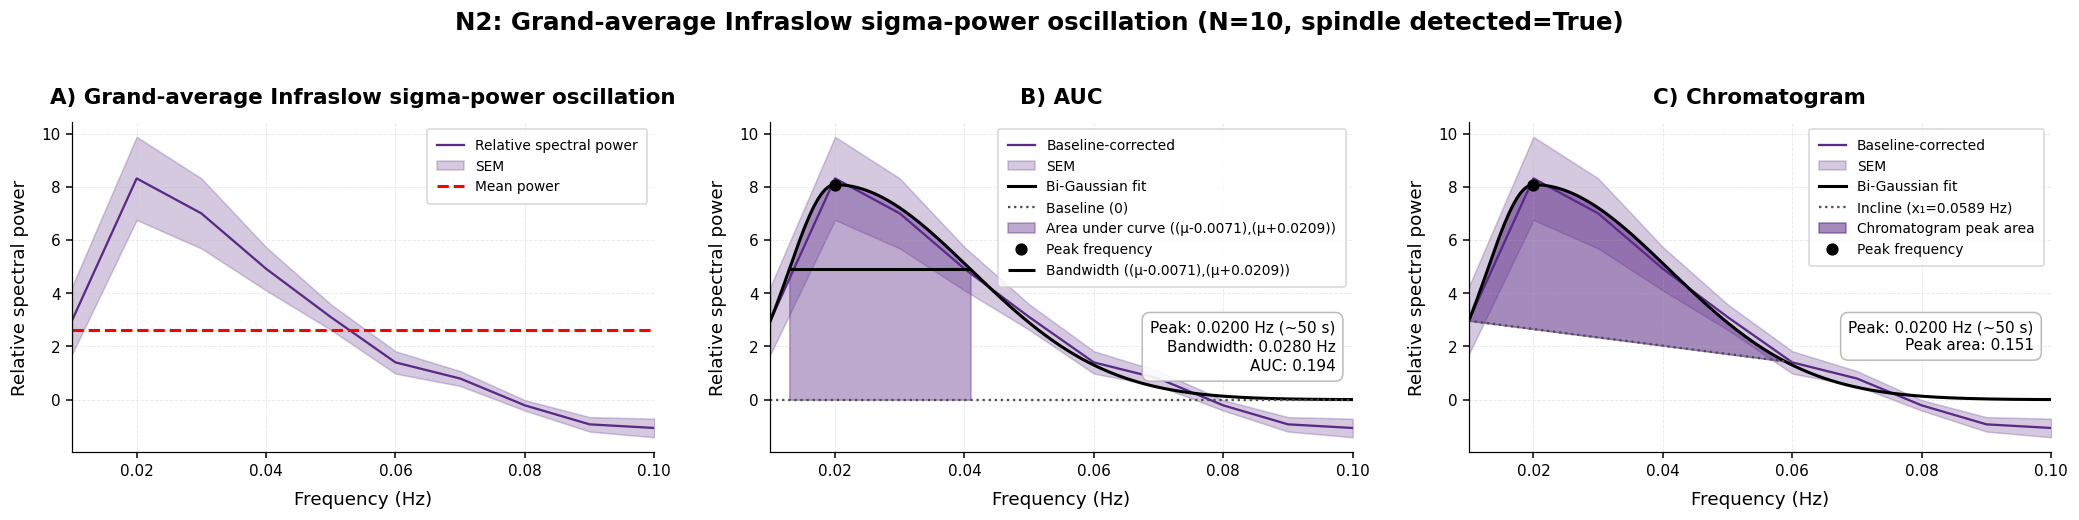

N2: ISFS detected True | peak 0.0200 Hz (~50 s) | bandwidth 0.0280 Hz | AUC((μ-0.0071),(μ+0.0209)) 0.194 | chromatogram peak area 0.151 (intersection at 0.0589 Hz) | n=10
SD L: 0.0013006944702531312 , SD R: 0.01


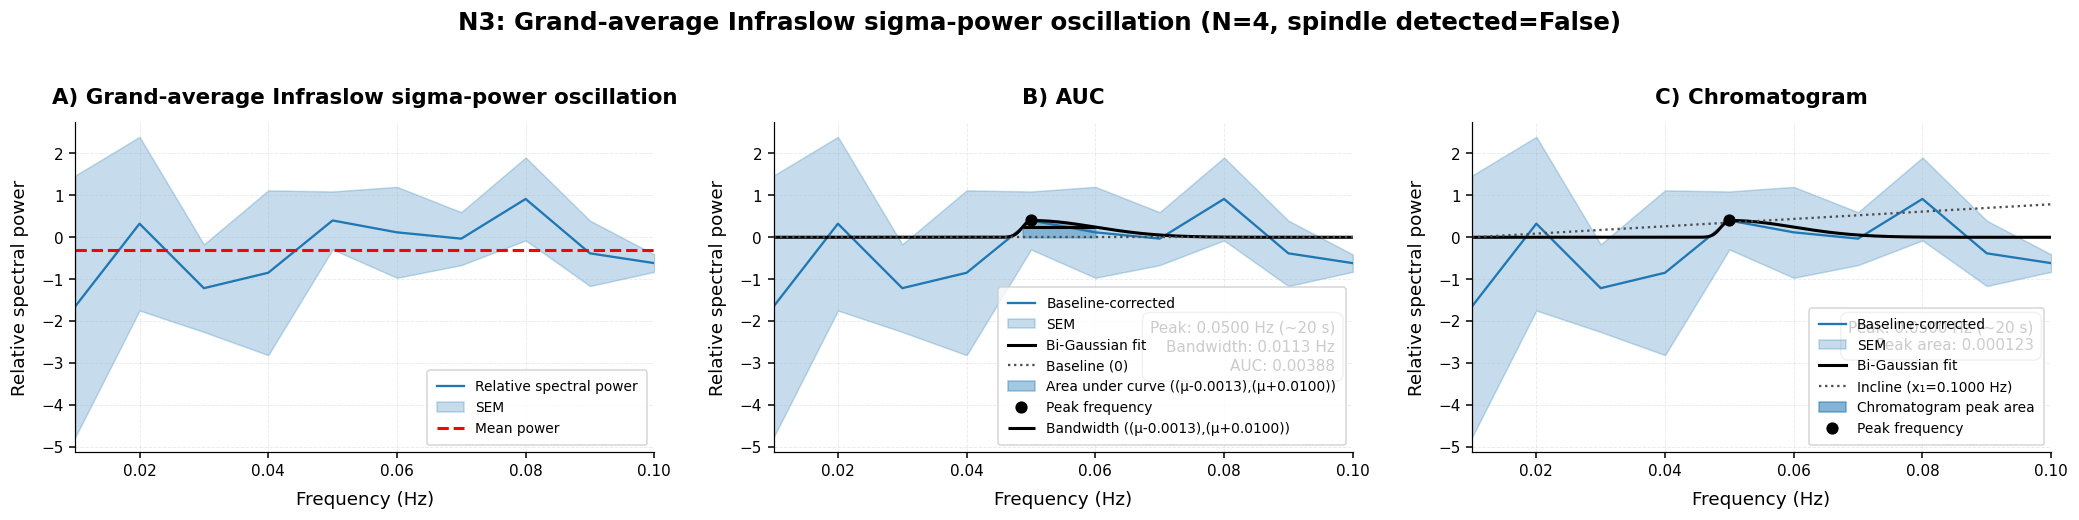

N3: ISFS detected False | peak 0.0500 Hz (~20 s) | bandwidth 0.0113 Hz | AUC((μ-0.0013),(μ+0.0100)) 0.00388 | chromatogram peak area 0.000123 (intersection at 0.1000 Hz) | n=4
SD L: 0.00725392663517299 , SD R: 0.02058590713923263


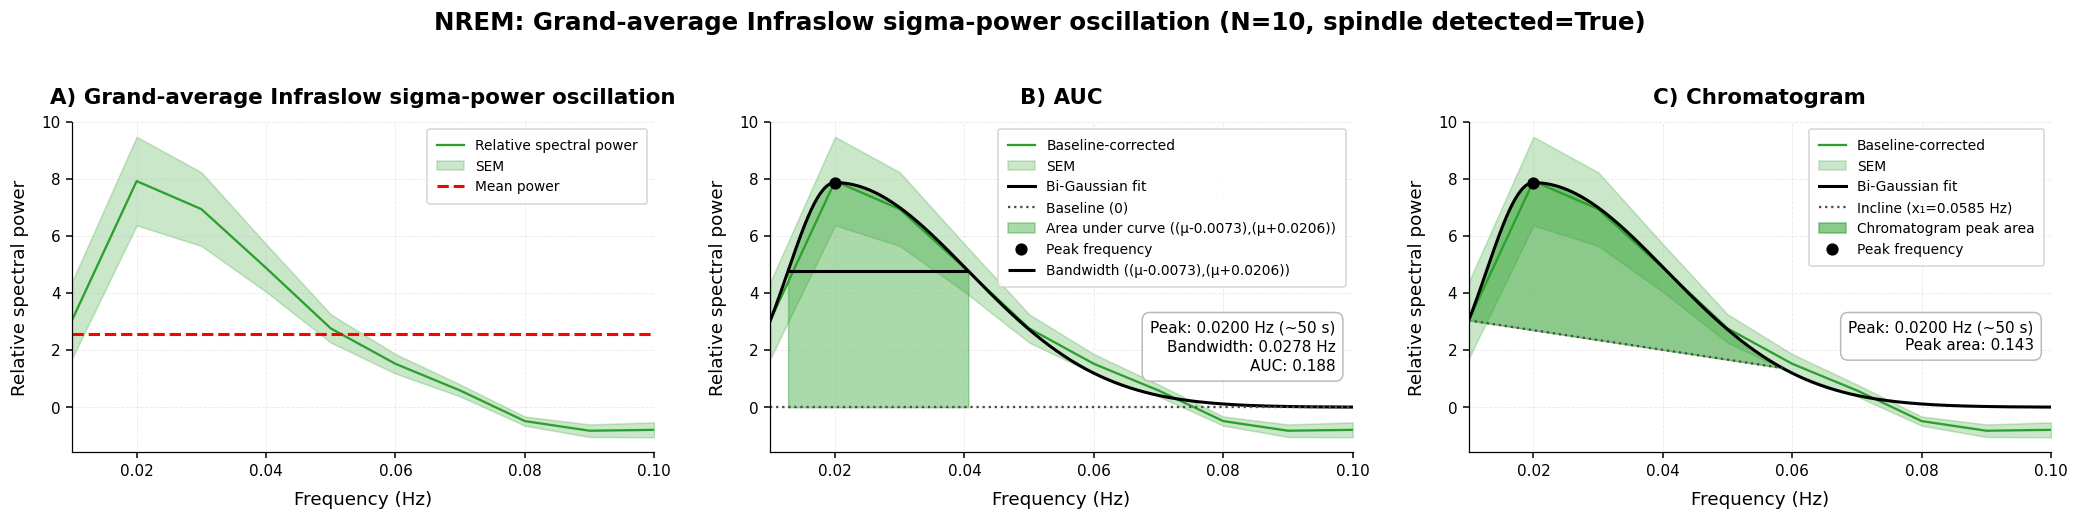

NREM: ISFS detected True | peak 0.0200 Hz (~50 s) | bandwidth 0.0278 Hz | AUC((μ-0.0073),(μ+0.0206)) 0.188 | chromatogram peak area 0.143 (intersection at 0.0585 Hz) | n=10


In [ ]:
# UI-only font settings
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12
TICK_FONTSIZE = 10
LEGEND_FONTSIZE = 9
ANNOTATION_FONTSIZE = 10
SUPTITLE_FONTSIZE = 16

results = {}

for stage in INFRASLOW_STAGES:
    freqs = freqs_by_stage[stage]
    curves = curves_by_stage[stage]
    n = len(curves)

    mean_curve = curves.mean(axis=0)
    sem_curve = curves.std(axis=0, ddof=1) / np.sqrt(n)

    fit = fit_isfs(freqs, mean_curve)

    fg = np.linspace(*INFRASLOW_BAND, 400)
    fitted_curve = bigaussian(fg, *fit["popt"])

    # The bi-Gaussian fit is constrained to amp >= 0, so it only decays toward
    # zero asymptotically. The dynamic intersection point is where it drops to
    # the same 1.5xSD threshold used for ISFS `detected`, not an exact zero.
    peak = chromatogram_peak_area(
        fg,
        fitted_curve,
        threshold=fit["threshold"],
    )

    results[stage] = {
        "n": n,
        "freqs": freqs,
        "mean": mean_curve,
        "sem": sem_curve,
        "fit": fit,
        "peak_area": peak["area"],
    }

    color = STAGE_COLORS[stage]

    fig, (axA, axB, axC) = plt.subplots(
        1,
        3,
        figsize=(19, 4.5),
    )

    # ==============================================================
    # A) Grand-average Infraslow sigma-power oscillation
    # ==============================================================
    axA.plot(
        freqs,
        mean_curve,
        color=color,
        lw=1.5,
        label="Relative spectral power",
    )

    axA.fill_between(
        freqs,
        mean_curve - sem_curve,
        mean_curve + sem_curve,
        color=color,
        alpha=0.25,
        label="SEM",
    )

    axA.axhline(
        mean_curve.mean(),
        color="red",
        lw=2,
        ls="--",
        label="Mean power",
    )

    axA.set_xlim(INFRASLOW_BAND)

    axA.set_xlabel(
        "Frequency (Hz)",
        fontsize=LABEL_FONTSIZE,
        labelpad=8,
    )

    axA.set_ylabel(
        "Relative spectral power",
        fontsize=LABEL_FONTSIZE,
        labelpad=8,
    )

    axA.set_title(
        "A) Grand-average Infraslow sigma-power oscillation",
        fontsize=TITLE_FONTSIZE,
        fontweight="semibold",
        pad=12,
    )

    axA.legend(
        frameon=True,
        fontsize=LEGEND_FONTSIZE,
        borderpad=0.7,
        labelspacing=0.5,
    )

    # ==============================================================
    # B) AUC
    # ==============================================================
    axB.plot(
        freqs,
        mean_curve,
        color=color,
        lw=1.5,
        label="Baseline-corrected",
    )

    axB.fill_between(
        freqs,
        mean_curve - sem_curve,
        mean_curve + sem_curve,
        color=color,
        alpha=0.25,
        label="SEM",
    )

    axB.plot(
        fg,
        fitted_curve,
        color="k",
        lw=2,
        label="Bi-Gaussian fit",
    )

    axB.axhline(
        0.0,
        ls=":",
        color="0.3",
        label="Baseline (0)",
    )

    f_auc = np.linspace(
        fit["lo"],
        fit["hi"],
        400,
    )

    axB.fill_between(
        f_auc,
        bigaussian(f_auc, *fit["popt"]),
        color=color,
        alpha=0.4,
        label=f"Area under curve ((μ-{fit['sd_l']:.4f}),(μ+{fit['sd_r']:.4f}))",
    )

    axB.plot(
        [fit["mu"]],
        [fit["amp"]],
        "o",
        color="k",
        ms=7,
        zorder=5,
        label="Peak frequency",
    )

    axB.hlines(
        bigaussian(fit["lo"], *fit["popt"]),
        fit["lo"],
        fit["hi"],
        color="k",
        lw=2,
        label=f"Bandwidth ((μ-{fit['sd_l']:.4f}),(μ+{fit['sd_r']:.4f}))",
    )

    axB.text(
        0.97,
        0.40,
        f"Peak: {fit['mu']:.4f} Hz (~{1 / fit['mu']:.0f} s)\n"
        f"Bandwidth: {fit['bandwidth']:.4f} Hz\n"
        # f"SD left: {fit['sd_l']:.4f}\n"
        # f"SD right: {fit['sd_r']:.4f}\n"
        f"AUC: {fit['auc']:.3g}",
        transform=axB.transAxes,
        ha="right",
        va="top",
        fontsize=ANNOTATION_FONTSIZE,
        linespacing=1.35,
        bbox={
            "boxstyle": "round,pad=0.5",
            "fc": "white",
            "ec": "0.7",
            "alpha": 0.9,
        },
    )

    axB.set_xlim(INFRASLOW_BAND)

    axB.set_xlabel(
        "Frequency (Hz)",
        fontsize=LABEL_FONTSIZE,
        labelpad=8,
    )

    axB.set_ylabel(
        "Relative spectral power",
        fontsize=LABEL_FONTSIZE,
        labelpad=8,
    )

    axB.set_title(
        "B) AUC",
        fontsize=TITLE_FONTSIZE,
        fontweight="semibold",
        pad=12,
    )

    axB.legend(
        frameon=True,
        fontsize=LEGEND_FONTSIZE,
        borderpad=0.7,
        labelspacing=0.5,
    )

    # ==============================================================
    # C) Chromatogram
    # ==============================================================
    axC.plot(
        freqs,
        mean_curve,
        color=color,
        lw=1.5,
        label="Baseline-corrected",
    )

    axC.fill_between(
        freqs,
        mean_curve - sem_curve,
        mean_curve + sem_curve,
        color=color,
        alpha=0.25,
        label="SEM",
    )

    axC.plot(
        fg,
        fitted_curve,
        color="k",
        lw=2,
        label="Bi-Gaussian fit",
    )

    axC.plot(
        [peak["x0"], peak["x1"]],
        [peak["y0"], peak["threshold"]],
        color="0.3",
        lw=1.5,
        ls=":",
        label=f"Incline (x₁={peak['x1']:.4f} Hz)",
    )

    axC.fill_between(
        peak["freqs"],
        peak["incline"],
        peak["curve"],
        where=peak["curve"] >= peak["incline"],
        color=color,
        alpha=0.55,
        label="Chromatogram peak area",
    )

    axC.plot(
        [fit["mu"]],
        [fit["amp"]],
        "o",
        color="k",
        ms=7,
        zorder=5,
        label="Peak frequency",
    )

    axC.text(
        0.97,
        0.40,
        f"Peak: {fit['mu']:.4f} Hz (~{1 / fit['mu']:.0f} s)\n"
        f"Peak area: {peak['area']:.3g}",
        transform=axC.transAxes,
        ha="right",
        va="top",
        fontsize=ANNOTATION_FONTSIZE,
        bbox={
            "boxstyle": "round,pad=0.5",
            "fc": "white",
            "ec": "0.7",
            "alpha": 0.9,
        },
    )

    axC.set_xlim(INFRASLOW_BAND)

    axC.set_xlabel(
        "Frequency (Hz)",
        fontsize=LABEL_FONTSIZE,
        labelpad=8,
    )

    axC.set_ylabel(
        "Relative spectral power",
        fontsize=LABEL_FONTSIZE,
        labelpad=8,
    )

    axC.set_title(
        "C) Chromatogram",
        fontsize=TITLE_FONTSIZE,
        fontweight="semibold",
        pad=12,
    )

    axC.legend(
        frameon=True,
        fontsize=LEGEND_FONTSIZE,
        borderpad=0.7,
        labelspacing=0.5,
    )

    # ==============================================================
    # Shared visual styling
    # ==============================================================
    for ax in (axA, axB, axC):
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=TICK_FONTSIZE,
            length=4,
            width=1,
        )

        ax.grid(
            True,
            which="major",
            axis="both",
            linestyle="--",
            linewidth=0.6,
            alpha=0.25,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Overall figure title
    fig.suptitle(
        f"{stage}: Grand-average Infraslow sigma-power oscillation "
        f"(N={n}, spindle detected={fit['detected']})",
        fontsize=SUPTITLE_FONTSIZE,
        fontweight="bold",
        y=1.04,
    )

    fig.tight_layout(
        w_pad=2.5,
    )

    plt.show()

    print(
        f"{stage}: ISFS detected {fit['detected']} | "
        f"peak {fit['mu']:.4f} Hz (~{1 / fit['mu']:.0f} s) | "
        f"bandwidth {fit['bandwidth']:.4f} Hz | "
        f"AUC((μ-{fit['sd_l']:.4f}),(μ+{fit['sd_r']:.4f})) {fit['auc']:.3g} | "
        f"chromatogram peak area {peak['area']:.3g} "
        f"(intersection at {peak['x1']:.4f} Hz) | "
        f"n={n}"
    )

## Grand-average ISFS summary across stages

In [ ]:
summary = pd.DataFrame([
    {
        'stage': stage,
        'n': r['n'],
        'peak_freq_hz': r['fit']['mu'],
        'peak_period_s': 1 / r['fit']['mu'],
        'bandwidth_hz': r['fit']['bandwidth'],
        'auc_pm1sd': r['fit']['auc'],
        'chromatogram_peak_area': r['peak_area'],
        'detected': r['fit']['detected'],
    }
    for stage, r in results.items()
]).set_index('stage')
summary

,n,peak_freq_hz,peak_period_s,bandwidth_hz,auc_pm1sd,chromatogram_peak_area,detected
stage,,,,,,,
N2,10,0.02,50.0,0.027999,0.193534,0.151062,True
N3,4,0.05,20.0,0.011301,0.003878,0.000123,False
NREM,10,0.02,50.0,0.027840,0.187671,0.143165,True


## Statistical comparison of AUC and chromatogram peak area across stages

The summary above is one number per stage, fit on the *grand-average* curve. To
test whether AUC and chromatogram peak area genuinely differ across N2/N3/NREM,
each subject's own curve is fit individually below (same `fit_isfs` /
`chromatogram_peak_area` used for the grand-average plots), giving one
independent value per subject per stage. Each fit is ~13 ms and independent
of every other subject's, so `per_subject_metrics` runs them across a process
pool sized to the Slurm-allocated CPU count (`N_WORKERS`) instead of one at a
time -- wall time scales down accordingly (e.g. ~35-40 min serial becomes
roughly that divided by `N_WORKERS` cores) -- the progress bar shows a live
ETA per stage.

Because AUC and peak area are non-negative and right-skewed (not normally
distributed), the comparison uses the non-parametric **Kruskal-Wallis H-test**
across all three stages, then Holm-corrected pairwise **Mann-Whitney U**
post-hoc tests. With tens of thousands of subjects per stage, even a negligible
difference will read as statistically significant -- the **rank-biserial effect
size** and the median difference (not just p) indicate whether a difference is
practically meaningful.

In [ ]:
_worker_freqs = None
_worker_fg = None


def _init_worker(freqs):
    """Runs once per worker process at pool startup -- `freqs` and the fixed
    evaluation grid `fg` are the same for every subject in a stage, so each
    worker stores its own copy instead of it being re-sent with every task.
    """
    global _worker_freqs, _worker_fg
    _worker_freqs = freqs
    _worker_fg = np.linspace(*INFRASLOW_BAND, 200)


def _fit_one(id_curve):
    subj_id, curve = id_curve
    try:
        fit = fit_isfs(_worker_freqs, curve)
    except RuntimeError:
        return subj_id, None, None
    fitted = bigaussian(_worker_fg, *fit['popt'])
    peak = chromatogram_peak_area(_worker_fg, fitted, threshold=fit['threshold'])
    return subj_id, fit['auc'], peak['area']


def per_subject_metrics(freqs, curves, ids, stage, n_workers=N_WORKERS):
    """Per-subject AUC (+/-1 SD) and chromatogram peak area, fit individually on
    each subject's own curve -- not read off the grand-average -- so the two
    metrics can be compared statistically across stages. Subject IDs travel
    alongside the fits (and are dropped in lockstep with a subject whose fit
    raises `RuntimeError`) so results stay attributable to a specific subject
    for cross-stage normalization later.

    Each subject's fit is independent of every other's, so this is an
    embarrassingly parallel problem: fits run across `n_workers` processes
    (matching the Slurm-allocated CPU count) instead of one subject at a time in
    the main process.
    """
    chunksize = max(1, len(curves) // (n_workers * 4))
    kept_ids, aucs, areas = [], [], []
    with ProcessPoolExecutor(max_workers=n_workers, initializer=_init_worker,
                              initargs=(freqs,)) as pool:
        results = pool.map(_fit_one, zip(ids, curves), chunksize=chunksize)
        for subj_id, auc, area in tqdm(results, total=len(curves),
                                        desc=f'{stage}: per-subject fits', unit='subject'):
            if auc is None:
                continue
            kept_ids.append(subj_id)
            aucs.append(auc)
            areas.append(area)
    return kept_ids, np.array(aucs), np.array(areas)


per_subject = {}
for stage in INFRASLOW_STAGES:
    ids, aucs, areas = per_subject_metrics(freqs_by_stage[stage], curves_by_stage[stage], ids_by_stage[stage], stage)
    per_subject[stage] = dict(ids=ids, auc=aucs, peak_area=areas)
    print(f'{stage}: {len(aucs)}/{len(curves_by_stage[stage])} subjects with a usable per-subject fit')


N2: per-subject fits:   0%|          | 0/10 [00:00<?, ?subject/s]

SD L:SD L:SD L: 0.007061388104293118  0.01602911662851642 , SD R: 0.016977313836202372 , SD R: 0.0125401920537225150.01
 
SD L: SD L:, SD R:  0.0152921476444072160.0057608134308843990.014357356537418665 
, SD R: 0.01779612635390926 
SD L: , SD R:SD L:0.01658881356383792  , SD R: 0.022914254129896523 0.006513801810371937
 SD L:0.01486273053368311, SD R:
 0.023618370158878497
 SD L:0.005957123931663852SD L: 0.006954249810781219  , SD R: 0.0170123160995277740.009251497702336001  
, SD R: 0.01963582383858132, SD R:
 0.013012385373179466
N2: 10/10 subjects with a usable per-subject fit


N3: per-subject fits:   0%|          | 0/4 [00:00<?, ?subject/s]

SD L: SD L:0.01 0.0010000000022536285 , SD R: SD L: , SD R: 0.009017696208537297 
0.0114889323811417210.001036608316022375
 , SD R:SD L:  0.00120771805888875320.01 
, SD R: 0.01
N3: 4/4 subjects with a usable per-subject fit


NREM: per-subject fits:   0%|          | 0/10 [00:00<?, ?subject/s]

SD L: 0.013302907600288674 , SD R: 0.016294136483233256
SD L:SD L:SD L: 0.005964485339940192  0.014203052210349627, SD R:  0.01
, SD R:SD L:  0.015159337474688922 0.011652369397523139
 , SD R: SD L: 0.0118659715405622230.006726092532093650.007200346850865695 
 , SD R: , SD R:0.02864864340848873SD L: 
 0.019691574798200585
SD L:0.007159086076378227SD L:  0.009356380237700577 0.006389059249932368  , SD R:, SD R:  , SD R: 0.0211771346118255940.018123570035275770.009686703071802926


SD L: 0.008153331067657709 , SD R: 0.021209150115877318
NREM: 10/10 subjects with a usable per-subject fit


In [ ]:
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu


def compare_across_stages(metric_name):
    """Kruskal-Wallis across all stages, then Holm-corrected pairwise Mann-Whitney
    U post-hoc tests -- non-parametric since AUC/peak area are non-negative and
    right-skewed, not normally distributed.
    """
    groups = [per_subject[stage][metric_name] for stage in INFRASLOW_STAGES]
    h, p_kw = kruskal(*groups)

    rows = []
    for a, b in combinations(INFRASLOW_STAGES, 2):
        xa, xb = per_subject[a][metric_name], per_subject[b][metric_name]
        u, p_raw = mannwhitneyu(xa, xb, alternative='two-sided')
        rows.append({
            'pair': f'{a} vs {b}', 'n1': len(xa), 'n2': len(xb),
            'median_1': np.median(xa), 'median_2': np.median(xb),
            'U': u, 'p_raw': p_raw,
            'rank_biserial_r': 1 - 2 * u / (len(xa) * len(xb)),
        })
    posthoc = pd.DataFrame(rows).sort_values('p_raw').reset_index(drop=True)

    # Holm-Bonferroni step-down correction (monotone non-decreasing adjusted p)
    m = len(posthoc)
    running_max, p_holm = 0.0, []
    for i, p_raw in enumerate(posthoc['p_raw']):
        running_max = max(running_max, min(1.0, p_raw * (m - i)))
        p_holm.append(running_max)
    posthoc['p_holm'] = p_holm
    posthoc['significant (Holm, a=0.05)'] = posthoc['p_holm'] < 0.05
    return h, p_kw, posthoc


auc_h, auc_p, auc_posthoc = compare_across_stages('auc')
print(f"AUC (+/-1 SD): Kruskal-Wallis H={auc_h:.2f}, p={auc_p:.3g} across {list(INFRASLOW_STAGES)}")
display(auc_posthoc.round(4))

area_h, area_p, area_posthoc = compare_across_stages('peak_area')
print(f"chromatogram peak area: Kruskal-Wallis H={area_h:.2f}, p={area_p:.3g} across {list(INFRASLOW_STAGES)}")
display(area_posthoc.round(4))

AUC (+/-1 SD): Kruskal-Wallis H=6.97, p=0.0306 across ['N2', 'N3', 'NREM']


,pair,n1,n2,median_1,median_2,U,p_raw,rank_biserial_r,p_holm,"significant (Holm, a=0.05)"
0,N2 vs N3,10,4,0.1931,0.0188,37.0,0.0140,-0.85,0.0420,True
1,N3 vs NREM,4,10,0.0188,0.1759,3.0,0.0140,0.85,0.0420,True
2,N2 vs NREM,10,10,0.1931,0.1759,53.0,0.8501,-0.06,0.8501,False


chromatogram peak area: Kruskal-Wallis H=6.78, p=0.0337 across ['N2', 'N3', 'NREM']


,pair,n1,n2,median_1,median_2,U,p_raw,rank_biserial_r,p_holm,"significant (Holm, a=0.05)"
0,N2 vs N3,10,4,0.1439,0.0047,37.0,0.0140,-0.850,0.0420,True
1,N3 vs NREM,4,10,0.0047,0.1361,3.5,0.0235,0.825,0.0470,True
2,N2 vs NREM,10,10,0.1439,0.1361,53.0,0.8501,-0.060,0.8501,False


In [ ]:
stage_stats = pd.DataFrame({
    stage: {
        'n': len(per_subject[stage]['auc']),
        'auc_median': np.median(per_subject[stage]['auc']),
        'auc_iqr': np.subtract(*np.percentile(per_subject[stage]['auc'], [75, 25])),
        'peak_area_median': np.median(per_subject[stage]['peak_area']),
        'peak_area_iqr': np.subtract(*np.percentile(per_subject[stage]['peak_area'], [75, 25])),
    }
    for stage in INFRASLOW_STAGES
}).T
stage_stats.round(4)

,n,auc_median,auc_iqr,peak_area_median,peak_area_iqr
N2,10.0,0.1931,0.1160,0.1439,0.0919
N3,4.0,0.0188,0.0540,0.0047,0.0021
NREM,10.0,0.1759,0.1165,0.1361,0.0528


In [ ]:
def subject_metric_means(
    per_subject,
    metric_name,
    stages=INFRASLOW_STAGES,
):
    """
    Calculate each subject's mean of `metric_name` across available stages.

    Only finite metric values are included. NaN and infinite values are
    ignored. Subjects without any valid values are excluded from the result.

    Parameters
    ----------
    per_subject : dict
        Per-stage results containing subject IDs and metric arrays.

    metric_name : str
        Name of the metric to average, such as ``"auc"`` or ``"peak_area"``.

    stages : iterable
        Sleep stages to include.

    Returns
    -------
    dict
        Mapping from subject ID to the mean of all valid metric values
        available for that subject.
    """
    sums = {}
    counts = {}

    for stage in stages:
        stage_data = per_subject.get(stage)

        if not stage_data:
            continue

        subject_ids = stage_data.get("ids", [])
        metric_values = stage_data.get(metric_name, [])

        for subj_id, value in zip(subject_ids, metric_values):
            try:
                value = float(value)
            except (TypeError, ValueError):
                continue

            # Ignore NaN, positive infinity, and negative infinity.
            if not np.isfinite(value):
                continue

            sums[subj_id] = sums.get(subj_id, 0.0) + value
            counts[subj_id] = counts.get(subj_id, 0) + 1

    return {
        subj_id: sums[subj_id] / counts[subj_id]
        for subj_id in sums
        if counts[subj_id] > 0
    }


auc_subject_mean = subject_metric_means(
    per_subject,
    metric_name="auc",
)

peak_area_subject_mean = subject_metric_means(
    per_subject,
    metric_name="peak_area",
)


## Is AUC different from chromatogram peak area?

The two metrics above are computed from the *same* per-subject fit (AUC over a
fixed +/-1 SD window vs. chromatogram peak area over the full width down to the
1.5xSD threshold), so for a given subject/stage they're **paired**, not
independent, samples -- the Mann-Whitney U test used across stages doesn't apply
here. The matched-pairs analogue is the **Wilcoxon signed-rank test**, run
separately per stage on `(auc, peak_area)` pairs.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon


def compare_auc_vs_peak_area(stage):
    """
    Compare normalized AUC and chromatogram peak area using a paired
    Wilcoxon signed-rank test.

    Invalid pairs are excluded when:
    - AUC or peak area is NaN or infinite.
    - The subject-specific mean is missing.
    - The subject-specific mean is NaN, infinite, or zero.
    - The normalized value is NaN or infinite.
    """
    stage_data = per_subject.get(stage, {})

    ids = stage_data.get("ids", [])
    auc_values = stage_data.get("auc", [])
    peak_area_values = stage_data.get("peak_area", [])

    auc_normalized = []
    area_normalized = []
    valid_ids = []

    for subj_id, auc_raw, area_raw in zip(
        ids,
        auc_values,
        peak_area_values,
    ):
        # Subject must have valid baseline means for both metrics.
        if subj_id not in auc_subject_mean:
            continue

        if subj_id not in peak_area_subject_mean:
            continue

        try:
            auc_raw = float(auc_raw)
            area_raw = float(area_raw)
            auc_mean = float(auc_subject_mean[subj_id])
            area_mean = float(peak_area_subject_mean[subj_id])
        except (TypeError, ValueError):
            continue

        # Exclude NaN and infinite raw values or subject means.
        if not all(
            np.isfinite(value)
            for value in (auc_raw, area_raw, auc_mean, area_mean)
        ):
            continue

        # Avoid division by zero or numerically near-zero values.
        if np.isclose(auc_mean, 0.0) or np.isclose(area_mean, 0.0):
            continue

        auc_norm = auc_raw / auc_mean
        area_norm = area_raw / area_mean

        # Final validation after normalization.
        if not np.isfinite(auc_norm) or not np.isfinite(area_norm):
            continue

        valid_ids.append(subj_id)
        auc_normalized.append(auc_norm)
        area_normalized.append(area_norm)

    auc = np.asarray(auc_normalized, dtype=float)
    area = np.asarray(area_normalized, dtype=float)
    diff = area - auc

    n_valid = len(diff)
    n_excluded = len(ids) - n_valid

    # Wilcoxon cannot be performed without valid paired observations.
    if n_valid == 0:
        return {
            "stage": stage,
            "n": 0,
            "n_excluded": n_excluded,
            "median_auc_norm": None,
            "median_peak_area_norm": None,
            "median_diff (area - auc)": None,
            "wilcoxon_W": None,
            "p": None,
            "matched_rank_biserial_r": None,
            "significant (a=0.05)": False,
        }

    # scipy.stats.wilcoxon may raise an error when every difference is zero.
    if np.all(np.isclose(diff, 0.0)):
        stat = 0.0
        p = 1.0
    else:
        stat, p = wilcoxon(
            auc,
            area,
            zero_method="wilcox",
            alternative="two-sided",
        )

    n_pos = int(np.sum(diff > 0))
    n_neg = int(np.sum(diff < 0))
    n_nonzero = n_pos + n_neg

    effect = (
        (n_pos - n_neg) / n_nonzero
        if n_nonzero > 0
        else 0.0
    )

    return {
        "stage": stage,
        "n": n_valid,
        "n_excluded": n_excluded,
        "median_auc_norm": float(np.median(auc)),
        "median_peak_area_norm": float(np.median(area)),
        "median_diff (area - auc)": float(np.median(diff)),
        "wilcoxon_W": float(stat),
        "p": float(p),
        "matched_rank_biserial_r": float(effect),
        "significant (a=0.05)": bool(p < 0.05),
    }


auc_vs_area = (
    pd.DataFrame(
        [
            compare_auc_vs_peak_area(stage)
            for stage in INFRASLOW_STAGES
        ]
    )
    .set_index("stage")
)

auc_vs_area

,n,n_excluded,median_auc_norm,median_peak_area_norm,median_diff (area - auc),wilcoxon_W,p,matched_rank_biserial_r,significant (a=0.05)
stage,,,,,,,,,
N2,10,0,1.037809,1.091674,0.027763,17.0,0.322266,0.2,False
N3,4,0,0.284989,0.075892,0.005308,5.0,1.000000,0.0,False
NREM,10,0,1.050895,1.075083,-0.000649,24.0,0.769531,0.0,False
